# Mapping in Python


In [2]:
%load_ext pretty_jupyter 

# Introduction 

Mapping the unseen helps to unveil patterns hidden in the piles of data." In the realm of data science, mapping is a powerful tool that transforms numerical and categorical data into visual stories, helping us understand the spatial context of the data we analyze. This is crucial across various fields such as environmental management, urban planning, and public health, where geographic relationships can significantly influence outcomes and decisions.

Python, with its rich ecosystem of libraries, provides a comprehensive toolkit for geospatial analysis and mapping. Some of the key tools include:

- **GeoPandas**: An extension of pandas that supports spatial operations on geometric types, making it perfect for geospatial data manipulations.
- **Matplotlib** and **Plotly**: While Matplotlib offers basic plotting tools, including mapping capabilities, Plotly brings interactive elements to the maps, enhancing user engagement and the depth of analysis.
- **Folium**: Leverages the strengths of Leaflet.js for creating interactive maps. Folium makes it easy to visualize data that’s been manipulated in Python on an interactive Leaflet map.
- **Contextily**: Adds contextual maps from tile providers, enriching the visual presentation of maps created with libraries like GeoPandas.

In this work through, we will guide you from the initial steps of handling geospatial data to creating detailed maps that narrate the story behind the data. Whether you're new to the field of geospatial analysis or seeking to enhance your mapping skills with Python, this guide is designed to equip you with the foundational knowledge and tools to start visualizing geographic data effectively. Let's set up our environment and dive into our first mapping example, where we'll analyze road accident data from Greater Manchester.


To effectively engage in mapping and geospatial analysis in Python, it's essential to set up your environment with the following libraries, each serving a specific function in the process:

| Library     | Description                                                        |
|-------------|--------------------------------------------------------------------|
| GeoPandas   | For geospatial data operations and manipulations.                  |
| Matplotlib  | For creating static maps and other types of plots.                 |
| Folium      | For building interactive maps that work well in web environments.   |
| Contextily  | To add basemap tiles to your plots for enhanced visual context.     |
| Shapely     | For detailed manipulation and analysis of geometric objects.       |
| Pandas      | For general data manipulation tasks, often necessary before spatial analysis. |
| Plotly      | For sophisticated interactive visualizations, including geospatial plots.    |


To ensure these libraries are available in your Python environment, you can install them using pip or conda.

!pip install geopandas  
!pip install matplotlib  
!pip install folium  
!pip install contextily  
!pip install shapely  
!pip install pandas  
!pip install plotly  

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import contextily as ctx
from shapely.geometry import Point, LineString, Polygon
import pandas as pd
import plotly.express as px

In this work through, we will only scratch the surface of what is possible in terms of mapping data. A great resource you may want to refer to if you do this more seriously is [Geocomputing in Python](https://py.geocompx.org/).

# Using Coordinates, Road Accident locations

We will utilize data on road traffic accidents in **Greater Manchester**. This data, detailing accidents from 2010 to 2021, can be found on the [Governmetn Data website government](https://data.gov.uk/dataset/25170a92-0736-4090-baea-bf6add82d118/gm-road-casualty-accidents-full-stats19-data) and typically includes coordinates that are essential for mapping. You must download the 'Road Safety Data - Accident 1979 2020.csv` file. This file contains information on every recorded road traffic accident between 2010 and 2021 in Greater Manchester.

Save this file (`STATS19_GM_AccData.csv`) in your working directory and load it into your Python environment.

In [7]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\Admin


In [9]:
os.chdir("C:/Users/Admin/Desktop/Pycode/ECLR/data")  # Replace with your desired path
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Users\Admin\Desktop\Pycode\ECLR\data


In [12]:
# Load the CSV file
accidents = pd.read_csv("STATS19_GM_AccData.csv")

Let's look at the structure of the dataset.

In [19]:
# Viewing the first few rows of the dataset
print(accidents.head())

   Accident Index  Year  Severity  NumberVehicles  NumberCasualties  \
0    102262412010  2010         3               2                 1   
1    102262562010  2010         3               2                 1   
2    102264322010  2010         3               2                 1   
3    107264182010  2010         3               3                 1   
4    114261842010  2010         3               1                 1   

   OutputDate  Day OutputTime  Easting  Northing  ...  Road2Class  \
0  01/01/2010    6      13:10   382347    390025  ...           3   
1  01/01/2010    6      11:10   381892    390582  ...           7   
2  01/01/2010    6      17:30   385840    403134  ...           7   
3  01/01/2010    6      13:49   377762    403302  ...           1   
4  01/01/2010    6      01:55   355982    404620  ...           0   

   Road2Number  PedCrossingHumanControl  PedCrossingPhysicalFacilities  \
0         5103                        0                              0   
1         

In [25]:
# Display structure and types of columns
accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42624 entries, 0 to 42623
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Accident Index                 42624 non-null  int64 
 1   Year                           42624 non-null  int64 
 2   Severity                       42624 non-null  int64 
 3   NumberVehicles                 42624 non-null  int64 
 4   NumberCasualties               42624 non-null  int64 
 5   OutputDate                     42624 non-null  object
 6   Day                            42624 non-null  int64 
 7   OutputTime                     42624 non-null  object
 8   Easting                        42624 non-null  int64 
 9   Northing                       42624 non-null  int64 
 10  LocalAuthority                 42624 non-null  int64 
 11  Road1Class                     42624 non-null  int64 
 12  Road1Number                    42624 non-null  int64 
 13  C

`accidents` dataset has 45,624 observations (or rows) and 27 variables (or columns). Each row represents an accident and for each accident we have the following information.

In [27]:
# Iterate through the column names and print each one
for column in accidents.columns:
    print(column)

Accident Index
Year
Severity
NumberVehicles
NumberCasualties
OutputDate
Day
OutputTime
Easting
Northing
LocalAuthority
Road1Class
Road1Number
CarriagewayType
SpeedLimit
JunctionDetail
JunctionControl
Road2Class
Road2Number
PedCrossingHumanControl
PedCrossingPhysicalFacilities
LightingCondition
WeatherCondition
RoadSurface
SpecialConditions
CarriagewayHazard
PlaceReported


Let's look at a particular accident. Let's randomly pick the **201st** accident in our dataset. In this case, we can use the the `.iloc indexer.` The which is used for integer-location based indexing and allows you to retrieve rows by their position in the DataFrame.

In [29]:
# Display the 201st accident in the dataset
accident_201 = accidents.iloc[200]  # Since indexing starts at 0, 201 is at index 200
print(accident_201)

Accident Index                   104268512010
Year                                     2010
Severity                                    3
NumberVehicles                              2
NumberCasualties                            2
OutputDate                         22/01/2010
Day                                         6
OutputTime                              21:40
Easting                                392197
Northing                               404013
LocalAuthority                            104
Road1Class                                  6
Road1Number                                 0
CarriagewayType                             6
SpeedLimit                                 30
JunctionDetail                              3
JunctionControl                             4
Road2Class                                  7
Road2Number                                 0
PedCrossingHumanControl                     0
PedCrossingPhysicalFacilities               0
LightingCondition                 

From this information, we get details of a specific road traffic accident from the dataset. More specifically, we observe that:

1. **Accident Year and Date**: The accident occurred in 2010, specifically on the 22nd of January. It was reported at 21:40.

2. **Severity and Impact**: The accident is categorized under severity level 3, involving two vehicles and resulting in 2 casualties. The severity level might need further interpretation from your data dictionary to understand its implications fully, typically ranging from minor to severe.

3. **Location**: The accident occurred at the coordinates given by the 'Easting' and 'Northing' values (392197, 404013). These coordinates pinpoint the location within the specified local authority area, potentially useful for mapping and spatial analysis.

4. **Speed and Road Conditions**: The accident occurred on a road with a speed limit of 30 km/h. The road class is indicated as 6, which might require referencing a data dictionary to understand the type of road (major, minor, etc.).

5. **Weather and Lighting Conditions**: According to the 'WeatherCondition' coded as '1' and 'LightingCondition' coded as '4', the weather was fine without high winds, and the area was dark but illuminated by street lights at the time of the accident. These factors are crucial for assessing the environmental conditions during the incident. You can get more information about these variables at the [Data Dictionary](https://assets.publishing.service.gov.uk/government/uploads/system/uploads/attachment_data/file/995422/stats19.pdf).

6. **Junction and Road Surface Details**: The 'JunctionDetail' and 'JunctionControl' fields are coded as 3 and 4, respectively, suggesting specific types of road junctions and control mechanisms in place, which could influence accident circumstances.

7. **Additional Conditions**: The dataset also includes information like 'CarriagewayType', 'RoadSurface', and 'CarriagewayHazard', all contributing to understanding the road conditions and potential hazards during the accident.

In this Python mapping walkthrough, we will focus on the accident location, captured by the 'Easting' and 'Northing' coordinates. These coordinates represent a specific location within the Greater Manchester area at Easting 392197 and Northing 404013.

To understand where these coordinates pinpoint geographically, you can use tools like the [Grid Reference Finder](https://gridreferencefinder.com/) or any other online map that supports British National Grid references. According to this mapping tool, the location is near Chamber Rd in Greater Manchester.

The concept of Easting and Northing is used in the UK Ordnance Survey to denote distances in meters east and north from the origin of the grid, which is set at a point southwest of the UK, essentially in the Atlantic Ocean. This reference system allows for precise location plotting within the United Kingdom, which is essential for spatial analysis and mapping in Python using libraries like `GeoPandas` and `Folium`.

Given that the Easting and Northing information is sufficient, we can display the geographic features of this dataset. Here, to plot geographic data we are using the powerful `lets-plot` package for data visualization in Python. It is inspired by `ggplot2` from R, aiming to provide a similar declarative interface for Python users. It's especially suited for statistical visualizations and is adept at handling both small and large datasets. Lets-Plot integrates well with the common data manipulation libraries in Python, such as Pandas, and it excels at creating complex multi-layered graphics.

In [37]:
from lets_plot import *
LetsPlot.setup_html()

# Create a plot using the Lets-Plot library
plot = (ggplot(accidents, aes('Easting', 'Northing')) +
        geom_point(color='black', size=0.5, alpha=0.5) +
        ggsize(1000, 600) +  # Set size in pixels
        theme(axis_text_x=element_text(angle=90, hjust=1))  # Rotate x-axis labels for better readability
       )

# Display the plot
plot.show()


You can basically see where in Manchester accidents happened. In essence you can see the Manchester Road network. Next, let's use `lets_plot`, to map the vehicle accidents in Greater Manchester by the class of road on which they occurred, using color to distinguish between different road classes:

In [58]:
# Lets-Plot setup
LetsPlot.setup_html()

# Ensure 'Road1Class' is a categorical variable for proper color mapping
accidents['Road1Class'] = accidents['Road1Class'].astype(str)

# Create the plot
plot = (ggplot(accidents, aes(x='Easting', y='Northing', color='Road1Class')) +
        geom_point(size=0.5, alpha=0.7) +  # Adjust the size and transparency of points
        scale_color_brewer(type='seq', palette='Blues', name="Road Class") +  # Sequential color scale
        ggsize(1000, 600) +  # Set the size of the plot
        ggtitle("Locations of vehicle accidents in Greater Manchester") +  # Add title
        theme(axis_title_x=element_text(size=12),  # Style axis titles
              axis_title_y=element_text(size=12),
              plot_title=element_text(size=16, face="bold")))

# Highlight the motorway ring road in black (assuming it's class '1')
highlight = accidents[accidents['Road1Class'] == '1']
highlight_plot = (ggplot(highlight, aes(x='Easting', y='Northing')) +
                  geom_point(color='black', size=0.7) +  # Black points for motorways
                  ggtitle("Motorway Ring Road Highlight"))

# Combine both plots (base plot + highlighted plot)
final_plot = plot + highlight_plot

# Display the plot
final_plot.show()


Darker roads (with lower `Road1Class` category) are main roads. You can clearly identify the motorway ring road.

# Using maps to illustrate regional differences 

A great tool to visualise the differences between regional entities (e.g. countries) is to produce a map where a color scale represents the values of some statistic. The first time you create maps, we are afraid, you will have to struggle a little. But the rewards are great! We start by uploading a few libraries we need to work with maps. We can follow the advice of the [Geocomputing in Python](https://py.geocompx.org/). and use some of the libraries below: 

1. `geopandas`: Equivalent to R's `sf`, this library is used for working with geospatial data and shapefiles. It integrates spatial data manipulation and visualization seamlessly.
2. `matplotlib` or `plotly`: For visualizing geospatial data. These provide a way to display maps and include colour scales for variables.
3. `Shapely`: Used for handling and analyzing geometries (e.g., polygons and lines).
4. `contextily`: For adding basemaps (e.g., OpenStreetMap tiles) to geospatial visualizations
5. `pyproj`: For handling projections and coordinate transformations.

It is also important to note that Python doesn’t have built-in shape files like R’s `spData` package, but you can download them from public resources, such as:

- [Natural Earth](https://www.naturalearthdata.com/) for global datasets.
- [GADM](https://gadm.org/) for detailed country-level administrative boundaries.

Alternatively, some Python libraries come with preloaded datasets like `geopandas`, including built-in datasets like `naturalearth_lowres` for global country shapes.

To display maps in Python, it's essential to have access to shapefiles that define the geometries of the regions or countries you wish to visualize. Shapefiles contain geometric data and attributes that describe the shapes and properties of geographical features. In Python, the GeoPandas library is commonly used to handle and visualize geospatial data. The `Geopandas`, has a built-in dataset for world country shapes and provides information about the shape and attributes of countries, similar to R's `world` dataset. 

In [66]:
import geopandas as gpd  # For handling geospatial data

# Load the preloaded "natural earth" dataset of world country shapes
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# View the first few rows to understand the dataset structure
print(world.head())

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

However, in this case, you will most likely encounter an error message. This is because the `geopandas.datasets` module has been deprecated in the newer versions of `GeoPanda's`. Therefore, you can utilize external datasets such as **Natural Earth** or **GADM (Global Administrative Areas)** to obtain country shapes for mapping in Python. Let's focus on GADM data. GADM provides detailed administrative boundary data for countries worldwide. To use GADM data:

- **Download the Data**:
 - Visit the [GADM Geodata repository](https://geodata.ucdavis.edu/gadm/gadm4.1/gadm_410-gpkg.zip).
 - Download the `gadm_410-gpkg.zip` file.
 - Extract the `.gpkg file` (GeoPackage format) from the zip file.

Once you download the zip file from the URL, do not forget to extract the `gadm_410.gpkg` file to your local working directory!

In [14]:
os.chdir("C:/Users/Admin/Desktop/Pycode/ECLR/data")  # Replace with your desired path
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Users\Admin\Desktop\Pycode\ECLR\data


In [16]:
import geopandas as gpd

# Path to the GPKG file in your working directory
gpkg_file = "gadm_410.gpkg"

# Load the GeoPackage file
boundaries = gpd.read_file(gpkg_file)

# Display the first few rows to verify
print(boundaries.head())


   UID GID_0       NAME_0 VARNAME_0    GID_1      NAME_1 VARNAME_1 NL_NAME_1  \
0    1   AFG  Afghanistan            AFG.1_1  Badakhshan  Badahšan             
1    2   AFG  Afghanistan            AFG.1_1  Badakhshan  Badahšan             
2    3   AFG  Afghanistan            AFG.1_1  Badakhshan  Badahšan             
3    4   AFG  Afghanistan            AFG.1_1  Badakhshan  Badahšan             
4    5   AFG  Afghanistan            AFG.1_1  Badakhshan  Badahšan             

  ISO_1 HASC_1  ... ENGTYPE_5 GOVERNEDBY    SOVEREIGN DISPUTEDBY REGION  \
0        AF.BD  ...                       Afghanistan                     
1        AF.BD  ...                       Afghanistan                     
2        AF.BD  ...                       Afghanistan                     
3        AF.BD  ...                       Afghanistan                     
4        AF.BD  ...                       Afghanistan                     

  VARREGION      COUNTRY CONTINENT SUBCONT  \
0            Afghanist

Let's see what information is contained in this file.

In [29]:
# Check the column names to understand what attributes are included
print("\nColumns in the dataset:")
print(boundaries.columns)


Columns in the dataset:
Index(['UID', 'GID_0', 'NAME_0', 'VARNAME_0', 'GID_1', 'NAME_1', 'VARNAME_1',
       'NL_NAME_1', 'ISO_1', 'HASC_1', 'CC_1', 'TYPE_1', 'ENGTYPE_1',
       'VALIDFR_1', 'GID_2', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'HASC_2',
       'CC_2', 'TYPE_2', 'ENGTYPE_2', 'VALIDFR_2', 'GID_3', 'NAME_3',
       'VARNAME_3', 'NL_NAME_3', 'HASC_3', 'CC_3', 'TYPE_3', 'ENGTYPE_3',
       'VALIDFR_3', 'GID_4', 'NAME_4', 'VARNAME_4', 'CC_4', 'TYPE_4',
       'ENGTYPE_4', 'VALIDFR_4', 'GID_5', 'NAME_5', 'CC_5', 'TYPE_5',
       'ENGTYPE_5', 'GOVERNEDBY', 'SOVEREIGN', 'DISPUTEDBY', 'REGION',
       'VARREGION', 'COUNTRY', 'CONTINENT', 'SUBCONT', 'geometry'],
      dtype='object')


In [60]:
# Get the structure of the dataset
print("\nDataset Info:")
boundaries.info()


Dataset Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 356508 entries, 0 to 356507
Data columns (total 53 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   UID         356508 non-null  int64   
 1   GID_0       356508 non-null  object  
 2   NAME_0      356508 non-null  object  
 3   VARNAME_0   356508 non-null  object  
 4   GID_1       356508 non-null  object  
 5   NAME_1      356508 non-null  object  
 6   VARNAME_1   356508 non-null  object  
 7   NL_NAME_1   356508 non-null  object  
 8   ISO_1       356508 non-null  object  
 9   HASC_1      356508 non-null  object  
 10  CC_1        356508 non-null  object  
 11  TYPE_1      356508 non-null  object  
 12  ENGTYPE_1   356508 non-null  object  
 13  VALIDFR_1   356508 non-null  object  
 14  GID_2       356508 non-null  object  
 15  NAME_2      356508 non-null  object  
 16  VARNAME_2   356508 non-null  object  
 17  NL_NAME_2   356508 non-null  object  
 18  H

In [33]:
# Display the coordinate reference system (CRS)
print("\nCoordinate Reference System (CRS):")
print(boundaries.crs)


Coordinate Reference System (CRS):
EPSG:4326


In [35]:
# Display the number of records
print("\nNumber of records in the dataset:")
print(len(boundaries))


Number of records in the dataset:
356508


From the Python output exploring the "boundaries" dataset, we see a comprehensive set of geographical data provided by the GADM database, which includes various attributes for different administrative levels around the world. Here are the key points to highlight:

1. **Data Structure and Attributes**: The dataset is structured into multiple columns including unique identifiers (`UID`, `GID_0`), descriptive names (`NAME_0`, `VARNAME_0`), and multiple levels of geographic detail from `NAME_0` to `NAME_5`. Each entry in the dataset has corresponding geographic data stored as polygons or multipolygons, which represent the shapes of geographical regions at various administrative levels.

2. **Coordinate Reference System (CRS)**: The dataset uses the EPSG:4326 reference system, which is commonly used for global geographic data and indicates that coordinates are stored in latitude and longitude.

3. **Content Richness**: The dataset includes not only geographic boundaries but also metadata like the type of administrative level, the governance details, and specifics about regional disputes which are crucial for detailed geospatial analysis.

4. **Dataset Size**: The dataset is extensive, with 356508 records, showing the depth and granularity of geographic data available for global regions.

Thus we can say that the dataset is ideal for creating detailed maps and performing regional analysis due to its comprehensive geographic and meta-data. 

Let's now inspect the geometry of a specific country, extract the shape details, and visualize them. 

[//]: # (-.- .tabset)

##### Step 1: Filter the Data for a Specific Country

In this case, let's choose "Norway" from our dataset.

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Filter for Norway using the NAME_0 column which contains country names
norway = boundaries[boundaries['NAME_0'] == 'Norway']

# Inspect the first few rows to ensure filtering is correct
print(norway.head())

           UID GID_0  NAME_0 VARNAME_0    GID_1    NAME_1       VARNAME_1  \
217228  217229   NOR  Norway            NOR.1_1  Akershus  Akershus fylke   
217229  217230   NOR  Norway            NOR.1_1  Akershus  Akershus fylke   
217230  217231   NOR  Norway            NOR.1_1  Akershus  Akershus fylke   
217231  217232   NOR  Norway            NOR.1_1  Akershus  Akershus fylke   
217232  217233   NOR  Norway            NOR.1_1  Akershus  Akershus fylke   

       NL_NAME_1 ISO_1 HASC_1  ... ENGTYPE_5 GOVERNEDBY SOVEREIGN DISPUTEDBY  \
217228                  NO.AK  ...                         Norway              
217229                  NO.AK  ...                         Norway              
217230                  NO.AK  ...                         Norway              
217231                  NO.AK  ...                         Norway              
217232                  NO.AK  ...                         Norway              

       REGION VARREGION COUNTRY CONTINENT SUBCONT  \
217

#####  Step 2: Inspect the Geometry Details
Let's check the detailed geometry of Norway:

In [ ]:
# Printing detailed geometry information for the first polygon
first_polygon = norway.geometry.iloc[0]
print("Polygon details (first polygon):")
print(first_polygon)

##### Step 3: Visualize the Geometry
Visualize the borders of Norway using a simple plot.

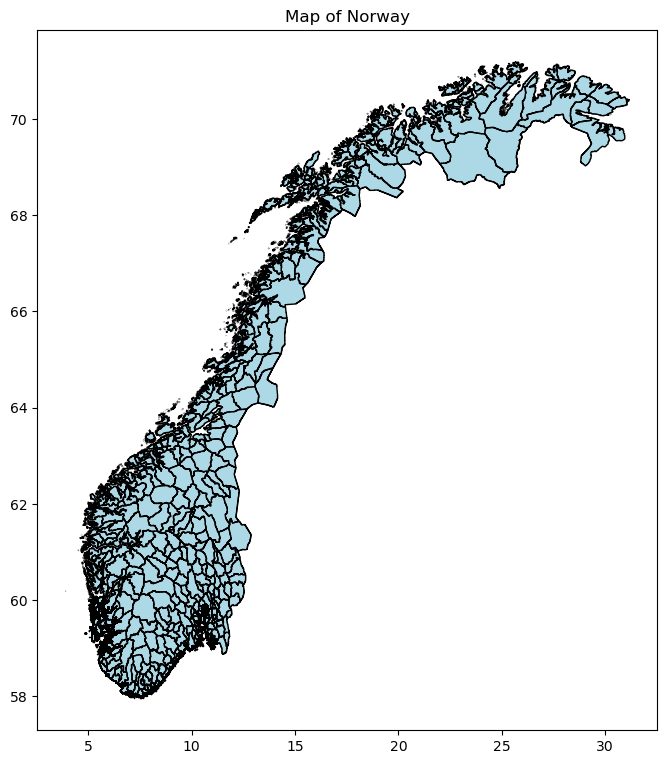

In [18]:
# Plotting the map
fig, ax = plt.subplots(1, 1, figsize=(8, 12))
norway.plot(ax=ax, color='lightblue', edgecolor='black')
plt.title('Map of Norway')
plt.show()

[//]: # (-.- .unlisted .unnumbered)

Of course, just creating a map of one country is somewhat boring. Let's create a map for only the countries in Africa. To create a map that visualizes only the countries in Africa using Python and `GeoPandas`, you'll need to filter the dataset to include only the countries on the African continent and then plot them. Here’s a step-by-step guide on how to do this:

[//]: # (-.- .tabset)

##### Step 1: Filter the Data for African Countries
You'll first filter your geospatial data to include only countries in Africa. This can typically be done using a 'CONTINENT' or similar column that specifies the continent for each country.

In [24]:
# Filter for African countries using the 'CONTINENT' column
africa = boundaries[boundaries['CONTINENT'] == 'Africa']

# Check the filtered data
print(africa.head())

     UID GID_0   NAME_0 VARNAME_0    GID_1 NAME_1 VARNAME_1   NL_NAME_1  \
726  727   DZA  Algeria            DZA.1_1  Adrar   Duperré  ولاية أدرا   
727  728   DZA  Algeria            DZA.1_1  Adrar   Duperré  ولاية أدرا   
728  729   DZA  Algeria            DZA.1_1  Adrar   Duperré  ولاية أدرا   
729  730   DZA  Algeria            DZA.1_1  Adrar   Duperré  ولاية أدرا   
730  731   DZA  Algeria            DZA.1_1  Adrar   Duperré  ولاية أدرا   

     ISO_1 HASC_1  ... ENGTYPE_5 GOVERNEDBY SOVEREIGN DISPUTEDBY REGION  \
726  DZ-01  DZ.AR  ...                        Algeria                     
727  DZ-01  DZ.AR  ...                        Algeria                     
728  DZ-01  DZ.AR  ...                        Algeria                     
729  DZ-01  DZ.AR  ...                        Algeria                     
730  DZ-01  DZ.AR  ...                        Algeria                     

    VARREGION  COUNTRY CONTINENT SUBCONT  \
726            Algeria    Africa           
727       

##### Step 2: Plotting the Map of Africa
Once you have the data filtered, you can create a plot to visualize all African countries.

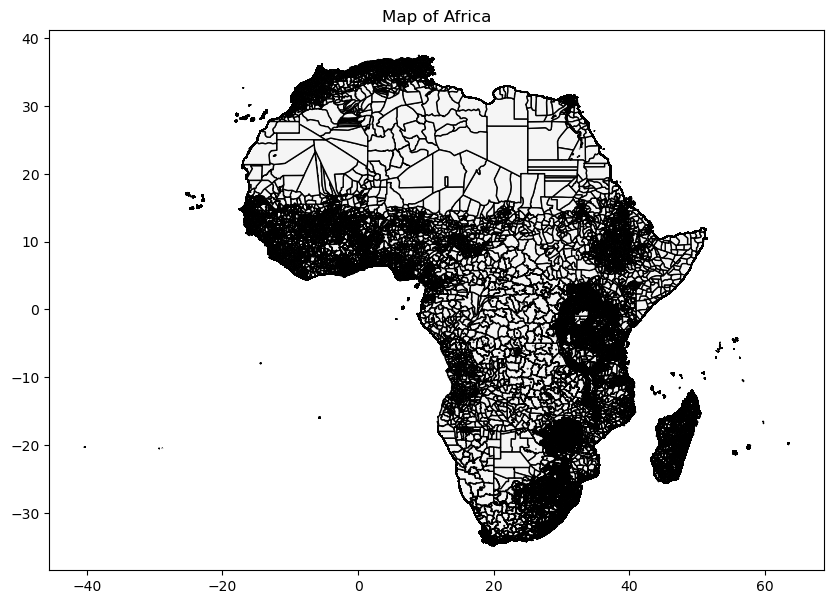

In [26]:
# Plotting the map of Africa
fig, ax = plt.subplots(1, 1, figsize=(10, 15))
africa.plot(ax=ax, color='whitesmoke', edgecolor='black')
ax.set_title('Map of Africa')
plt.show()

[//]: # (-.- .unlisted .unnumbered)

What if we wanted to consolidate all municipality boundaries for Norway and subtract the water bodies (`TYPE_1`) also present in the GADM data (`boundaries` dataset)? 

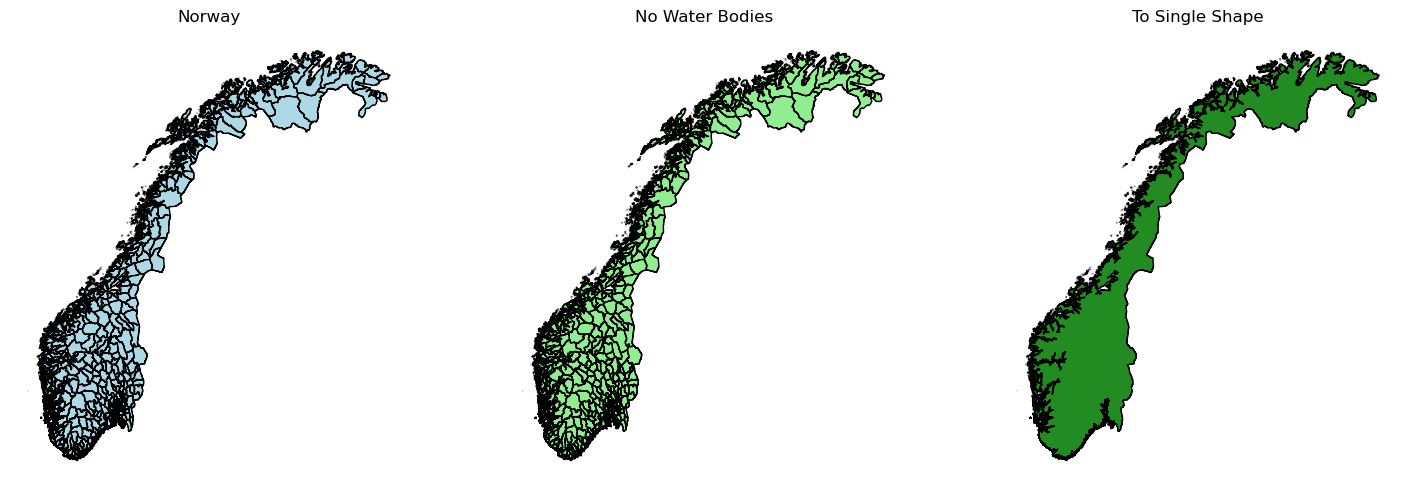

In [73]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Assuming 'boundaries' is the GeoDataFrame containing the GADM data

# Step 1: Filter for Norway
the_norway = boundaries.query("NAME_0 == 'Norway'")

# Step 2: Exclude water bodies
no_water_bodies = the_norway.query("TYPE_1 != 'Water body'")

# Step 3: Dissolve to create a single shape
to_single_shape = no_water_bodies.dissolve(by='NAME_0')

# Step 4: Visualize the three stages
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot the full Norway dataset
the_norway.plot(ax=axes[0], color='lightblue', edgecolor='black')
axes[0].set_title("Norway")

# Plot Norway without water bodies
no_water_bodies.plot(ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title("No Water Bodies")

# Plot Norway as a single shape
to_single_shape.plot(ax=axes[2], color='forestgreen', edgecolor='black')
axes[2].set_title("To Single Shape")

# Final adjustments
for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


- The first map shows the complete dataset for Norway, including all regional subdivisions and water bodies.
- The second map filters out water bodies, providing a clearer representation of the land areas in Norway.
- The third map consolidates all regions into a single unified shape, highlighting the overall geographic outline of the country.

This approach showcases how geospatial data can be transformed for varying levels of detail and insights.

This process was relatively straightforward because the dataset provides detailed geographic information for all regions, ready for visualization. But what if you want to zoom in on specific regions, such as regions within the UK, rather than entire countries? And what if you want to represent a different variable for these regions? 
In the next section, you will learn how to do this. But from this example, it becomes clear that three key elements are required:

- **A file containing the shape information** for the geographic entities (similar to the `geometry` column in the GeoDataFrame).
- **An object with the data** for each regional entity, representing the variable(s) you wish to display.
- **A common variable to merge these two datasets**, such as country names or standardized region codes (like ISO country codes).

These components provide the foundation for creating region-specific maps with customized visualizations.

## Using Imported Shape Files in Python: Local Authority Districts/ Boundaries UK BFC

Let's work on an example where we use geographic entities that require importing shape files. In Python, the package that facilitates this is GeoPandas, which makes it easy to work with geospatial data, including shapefiles. In order to find the shape files for these areas you will have to search the internet for such a file, for instance search for "UK Local Authority Districts shape file" and you will eventually find a place, such as [Office for National Statistics](https://geoportal.statistics.gov.uk/search?q=BDY_LAD%202024&sort=Title%7Ctitle%7Casc).

From there you can download a `shp` file. Here we downloaded the "Local Authority Districts (December 2024) Boundaries UK BFC" file. This will download a zipped folder called "Local_Authority_Districts_December_2024_Boundaries_UK_BFC_4880322208219286849". You need to unzip/extract this entire folder into your working directory. In your working directory you then have a folder called "Local_Authority_Districts_December_2024_Boundaries_UK_BFC_4880322208219286849" and in that folder you will find the following six file extensions:

- `.cpg`: Encodes the character set for the dataset.
- `.dbf`: Contains the attribute data for the shapefile.
- `.prj`: Specifies the coordinate reference system (CRS).
- `.shp`: Stores the geometry (the actual shapes of the boundaries).
- `.shp.xml`: Metadata describing the shapefile.
- `.shx`: Index file for quick access to the shapefile's geometry.

 Make sure all these files are in that folder. 


#### Loading the Shapefile in Python

To use the shapefile, we will load it into a **GeoDataFrame** using the `GeoPandas` library. This GeoDataFrame will allow us to perform spatial analysis, manipulate geometries, and visualize the dataset.

Here’s the Python code to load the shapefile and explore its structure:

In [31]:
os.chdir("C:/Users/Admin/Desktop/Pycode/ECLR/data")  # Replace with your desired path
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Users\Admin\Desktop\Pycode\ECLR\data


In [33]:
import geopandas as gpd

# Path to the shapefile in your working directory
shapefile_path = "Local_Authority_Districts_December_2024_Boundaries_UK_BFC_4880322208219286849"

# Load the shapefile into a GeoDataFrame
local_authority_districts = gpd.read_file(shapefile_path)

Let's explore the dataset

In [35]:
# Display the structure and column names of the dataset
print("\nDataset Information:")
local_authority_districts.info()


Dataset Information:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 361 entries, 0 to 360
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LAD24CD   361 non-null    object  
 1   LAD24NM   361 non-null    object  
 2   LAD24NMW  22 non-null     object  
 3   BNG_E     361 non-null    int64   
 4   BNG_N     361 non-null    int64   
 5   LONG      361 non-null    float64 
 6   LAT       361 non-null    float64 
 7   GlobalID  361 non-null    object  
 8   geometry  361 non-null    geometry
dtypes: float64(2), geometry(1), int64(2), object(4)
memory usage: 25.5+ KB


In [37]:
# Check rows 1 to 10
local_authority_districts.iloc[1:10]

,LAD24CD,LAD24NM,LAD24NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
1,E06000002,Middlesbrough,None,451141,516887,-1.21100,54.5447,57e29036-0011-4f2c-91c9-c6519866a7fb,"MULTIPOLYGON (((446854.7 517192.7, 446854.281 ..."
2,E06000003,Redcar and Cleveland,None,464330,519596,-1.00657,54.5675,f0039556-1c53-409c-8d3f-4ae11a008e66,"MULTIPOLYGON (((451747.397 520561.1, 451792.20..."
3,E06000004,Stockton-on-Tees,None,444940,518179,-1.30665,54.5569,9e2c43d3-1ff5-4c15-a27d-000fe3e72776,"MULTIPOLYGON (((447177.704 517811.797, 447176...."
4,E06000005,Darlington,None,428029,515648,-1.56836,54.5353,bd408dc5-ecde-4f5f-8fc9-92742cd343a3,"POLYGON ((423496.602 524724.299, 423497.204 52..."
5,E06000006,Halton,None,354246,382146,-2.68854,53.3343,65d61eb7-46a4-498d-b7c9-c3fe5ccefcd0,"MULTIPOLYGON (((358374.702 384376.803, 358367...."
6,E06000007,Warrington,None,362744,388457,-2.56168,53.3916,079185d9-2ae0-4e3f-be0c-dae1c492fb5c,"POLYGON ((367308.201 398265.497, 367315.399 39..."
7,E06000008,Blackburn with Darwen,None,369489,422806,-2.46362,53.7008,513d5442-fc64-4356-8e70-830fc3d4352b,"POLYGON ((369226.299 431801.198, 369234 431794..."
8,E06000009,Blackpool,None,332817,436635,-3.02203,53.8216,feeb9a21-5627-4acd-b70d-b5dc216b513d,"POLYGON ((332985.702 441693.996, 332941.5 4415..."
9,E06000010,"Kingston upon Hull, City of",None,511892,431651,-0.30386,53.7692,68acf4dd-9781-4ce4-8b3b-ec6e42ffd60e,"MULTIPOLYGON (((515903.4 428182.7, 515902.474 ..."


As you can indicate, the dataset contains 361 records, each representing a specific Local Authority District (LAD) in the UK and having nine pieces of information

- **LAD24CD**: A unique identifier for each Local Authority District in 2024. This serves as the primary code for referencing the districts.
- **LAD24NM**: The name of the Local Authority District (e.g., "Middlesbrough," "Blackpool"). This is a human-readable label for the districts.
- **LAD24NMW**: An additional field for district names in another format or language, but it is largely None in this dataset.
- **BNG_E (Easting)**: The Easting coordinate in the British National Grid (BNG) system, representing the horizontal spatial position of each district.
-**BNG_N (Northing)**: The Northing coordinate in the British National Grid system, representing the vertical spatial position of each district.
- **LONG (Longitude)**: The geographic longitude of the district's centroid in degrees.
- **LAT (Latitude)**: The geographic latitude of the district's centroid in degrees.
- **GlobalID**: A unique global identifier for each district, likely used for managing the data in geospatial databases.
- **geometry**: A key column that contains spatial data representing the boundaries of each district. These are stored as POLYGON or MULTIPOLYGON objects, which describe the shapes and locations of the districts.

The **geometry** column is essential for mapping and geospatial analysis. Each row contains a polygon or multipolygon object that defines the physical boundary of a district. Coordinates for polygons are defined in terms of the British National Grid (BNG) and geographic systems (latitude and longitude). Variables like `BNG_E`, `BNG_N`, `LONG`, and `LAT` provide multiple options for referencing spatial locations, either in the British National Grid system or globally.


Let's also visualize the dataset to confirm it has loaded correctly:

In [105]:
from lets_plot import *
import geopandas as gpd
import pandas as pd

# Initialize Lets-Plot
LetsPlot.setup_html()

# Assuming 'local_authority_districts' is already loaded
# Convert the MultiPolygon geometries into points (longitude and latitude)
exploded = local_authority_districts.explode(index_parts=False)

# Extract coordinates for exterior boundaries of polygons
plot_data = pd.DataFrame(
    [(geom.exterior.coords.xy[0], geom.exterior.coords.xy[1], name)
     for geom, name in zip(exploded.geometry, exploded['LAD24NM']) if geom.geom_type == 'Polygon' or geom.geom_type == 'MultiPolygon'],
    columns=['lon', 'lat', 'district']
)

# Flatten the coordinates and create a DataFrame for plotting
flat_data = pd.DataFrame({
    'lon': [lon for coords in plot_data['lon'] for lon in coords],
    'lat': [lat for coords in plot_data['lat'] for lat in coords],
    'district': plot_data['district'].repeat(plot_data['lon'].str.len())
})

# Create the plot using Lets-Plot
plot = ggplot(flat_data, aes(x='lon', y='lat', color='district')) + \
       geom_point(size=0.5, alpha=0.7) + \
       ggsize(1000, 800) + \
       ggtitle("Visualization of Local Authority Districts in the UK")

# Display the plot
plot.show()


##  Merging in data

Now that we have the geometry information for local authorities in the UK, we can merge this with some information about these areas. Here, we shall import information on the level of deprivation in each Local Authority. The index of multiple deprivation (IMD) is a measure which attempts to express how deprived (on several issues) an area is. The IMD measures deprivation across various dimensions such as income, employment, health, education, housing, crime, and living environment. Merging this with geographic data allows for spatial analysis of socio-economic conditions. For data acquisition, it is essential that


Performing a web search "UK index of multiple deprivation" will lead you to a number of places where you can download this information, for instance this [www.gov.uk site](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2019) from which you can download the 2019 version of the IMD ("File 1: Index of multiple deprivation"). Download the xlsx file and save it to your working directory.

In [39]:
os.chdir("C:/Users/Admin/Desktop/Pycode/ECLR/data")  # Replace with your desired path
print("New Working Directory:", os.getcwd())

New Working Directory: C:\Users\Admin\Desktop\Pycode\ECLR\data


In [41]:
import pandas as pd

# Load IMD data
imd_data = pd.read_excel('IMD2019_Index_of_Multiple_Deprivation.xlsx')

Let's explore the data

In [42]:
# Display the first few rows of the data
print(imd_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32844 entries, 0 to 32843
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   LSOA code (2011)                            32844 non-null  object
 1   LSOA name (2011)                            32844 non-null  object
 2   Local Authority District code (2019)        32844 non-null  object
 3   Local Authority District name (2019)        32844 non-null  object
 4   Index of Multiple Deprivation (IMD) Rank    32844 non-null  int64 
 5   Index of Multiple Deprivation (IMD) Decile  32844 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.5+ MB
None


In [45]:
# Check rows 1 to 10
imd_data.iloc[1:10]

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Rank,Index of Multiple Deprivation (IMD) Decile
1,E01000002,City of London 001B,E09000001,City of London,30379,10
2,E01000003,City of London 001C,E09000001,City of London,14915,5
3,E01000005,City of London 001E,E09000001,City of London,8678,3
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,14486,5
5,E01000007,Barking and Dagenham 015A,E09000002,Barking and Dagenham,7256,3
6,E01000008,Barking and Dagenham 015B,E09000002,Barking and Dagenham,5010,2
7,E01000009,Barking and Dagenham 016B,E09000002,Barking and Dagenham,6736,3
8,E01000010,Barking and Dagenham 015C,E09000002,Barking and Dagenham,6900,3
9,E01000011,Barking and Dagenham 016C,E09000002,Barking and Dagenham,7698,3


We now have two datasets (`local_authority_districts` and `imd_data`) with information on local authorities. From the information provided, it seems that you are ready to merge the two datasets based on their common identifier for local authorities, which appears to be labelled as `Local Authority District code (2019)` in the `imd_data` and `LAD24CD` in the `local_authority_districts`. One could argue that this is a suitable approach for merging these datasets for spatial analysis of socio-economic conditions.

Now we shall merge the data using `pandas`

In [49]:
import pandas as pd

# Load your datasets (make sure they are read correctly)
# For example:
# imd_data = pd.read_excel('imd_data.xlsx')
# local_authority_districts = gpd.read_file('local_authority_districts.shp')

# Merge the data on the Local Authority District code
merged_data = pd.merge(local_authority_districts, imd_data, left_on='LAD24CD', right_on='Local Authority District code (2019)', how='inner')

# Convert the merged DataFrame back to a GeoDataFrame if necessary
merged_data = gpd.GeoDataFrame(merged_data, geometry='geometry')

# Check the first few rows to confirm merge success
print(merged_data.head())


     LAD24CD     LAD24NM LAD24NMW   BNG_E   BNG_N     LONG      LAT  \
0  E06000001  Hartlepool     None  447161  531473 -1.27017  54.6761   
1  E06000001  Hartlepool     None  447161  531473 -1.27017  54.6761   
2  E06000001  Hartlepool     None  447161  531473 -1.27017  54.6761   
3  E06000001  Hartlepool     None  447161  531473 -1.27017  54.6761   
4  E06000001  Hartlepool     None  447161  531473 -1.27017  54.6761   

                               GlobalID  \
0  360c992d-5b53-4286-a891-21085a50ab7e   
1  360c992d-5b53-4286-a891-21085a50ab7e   
2  360c992d-5b53-4286-a891-21085a50ab7e   
3  360c992d-5b53-4286-a891-21085a50ab7e   
4  360c992d-5b53-4286-a891-21085a50ab7e   

                                            geometry LSOA code (2011)  \
0  MULTIPOLYGON (((450154.599 525938.201, 450140....        E01011949   
1  MULTIPOLYGON (((450154.599 525938.201, 450140....        E01011950   
2  MULTIPOLYGON (((450154.599 525938.201, 450140....        E01011951   
3  MULTIPOLYGON (((450

In [51]:
# Check rows 1 to 5
merged_data.iloc[1:5]

,LAD24CD,LAD24NM,LAD24NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Rank,Index of Multiple Deprivation (IMD) Decile
1,E06000001,Hartlepool,None,447161,531473,-1.27017,54.6761,360c992d-5b53-4286-a891-21085a50ab7e,"MULTIPOLYGON (((450154.599 525938.201, 450140....",E01011950,Hartlepool 008A,E06000001,Hartlepool,527,1
2,E06000001,Hartlepool,None,447161,531473,-1.27017,54.6761,360c992d-5b53-4286-a891-21085a50ab7e,"MULTIPOLYGON (((450154.599 525938.201, 450140....",E01011951,Hartlepool 007A,E06000001,Hartlepool,1663,1
3,E06000001,Hartlepool,None,447161,531473,-1.27017,54.6761,360c992d-5b53-4286-a891-21085a50ab7e,"MULTIPOLYGON (((450154.599 525938.201, 450140....",E01011952,Hartlepool 002A,E06000001,Hartlepool,3469,2
4,E06000001,Hartlepool,None,447161,531473,-1.27017,54.6761,360c992d-5b53-4286-a891-21085a50ab7e,"MULTIPOLYGON (((450154.599 525938.201, 450140....",E01011953,Hartlepool 002B,E06000001,Hartlepool,911,1


We have now a new object with the merged information on these local authorities. With the merged dataset, you can now perform spatial analysis. For example, creating a choropleth map to visualize the levels of deprivation across different local authorities can be insightful:

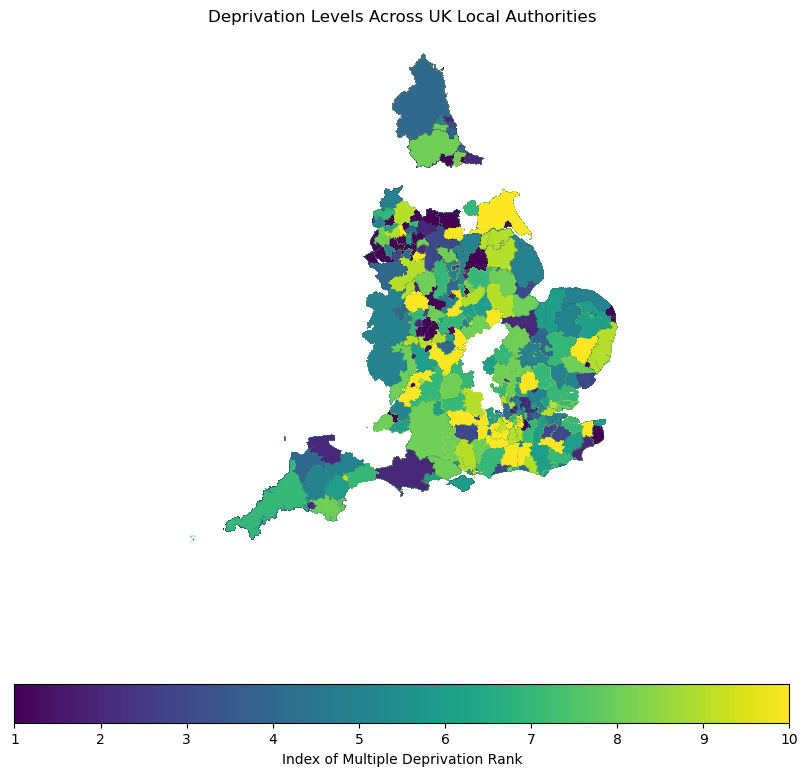

In [87]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Assuming merged_data is your final GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
merged_data.plot(column='Index of Multiple Deprivation (IMD) Decile', ax=ax, legend=True,
                 legend_kwds={'label': "Index of Multiple Deprivation Rank",
                              'orientation': "horizontal"})
ax.set_title('Deprivation Levels Across UK Local Authorities')
ax.set_axis_off()  # This hides the axis for a cleaner presentation

plt.show()


Let's now filter the dataset to only include specified local authorities and then plot each one individually with their respective IMD decile data. Assume that we want to focus on Sheffield, Leeds, Liverpool, and Newcastle from the merged dataset. 

[//]: # (-.- .tabset)

##### Step 1: Filter the Data

Extract the data for Sheffield, Leeds, Liverpool, and Coventry from your merged dataset. You will need to make sure your dataset has a column that clearly identifies the name of each local authority.

In [97]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Assuming 'merged_data' is your GeoDataFrame
# Filter for the required local authorities
cities = ['Sheffield', 'Leeds', 'Liverpool', 'Coventry']
filtered_data = merged_data[merged_data['Local Authority District name (2019)'].isin(cities)]

##### Step 2: Plotting
Create a function to plot each city individually:

[//]: # (-.- .unlisted .unnumbered)

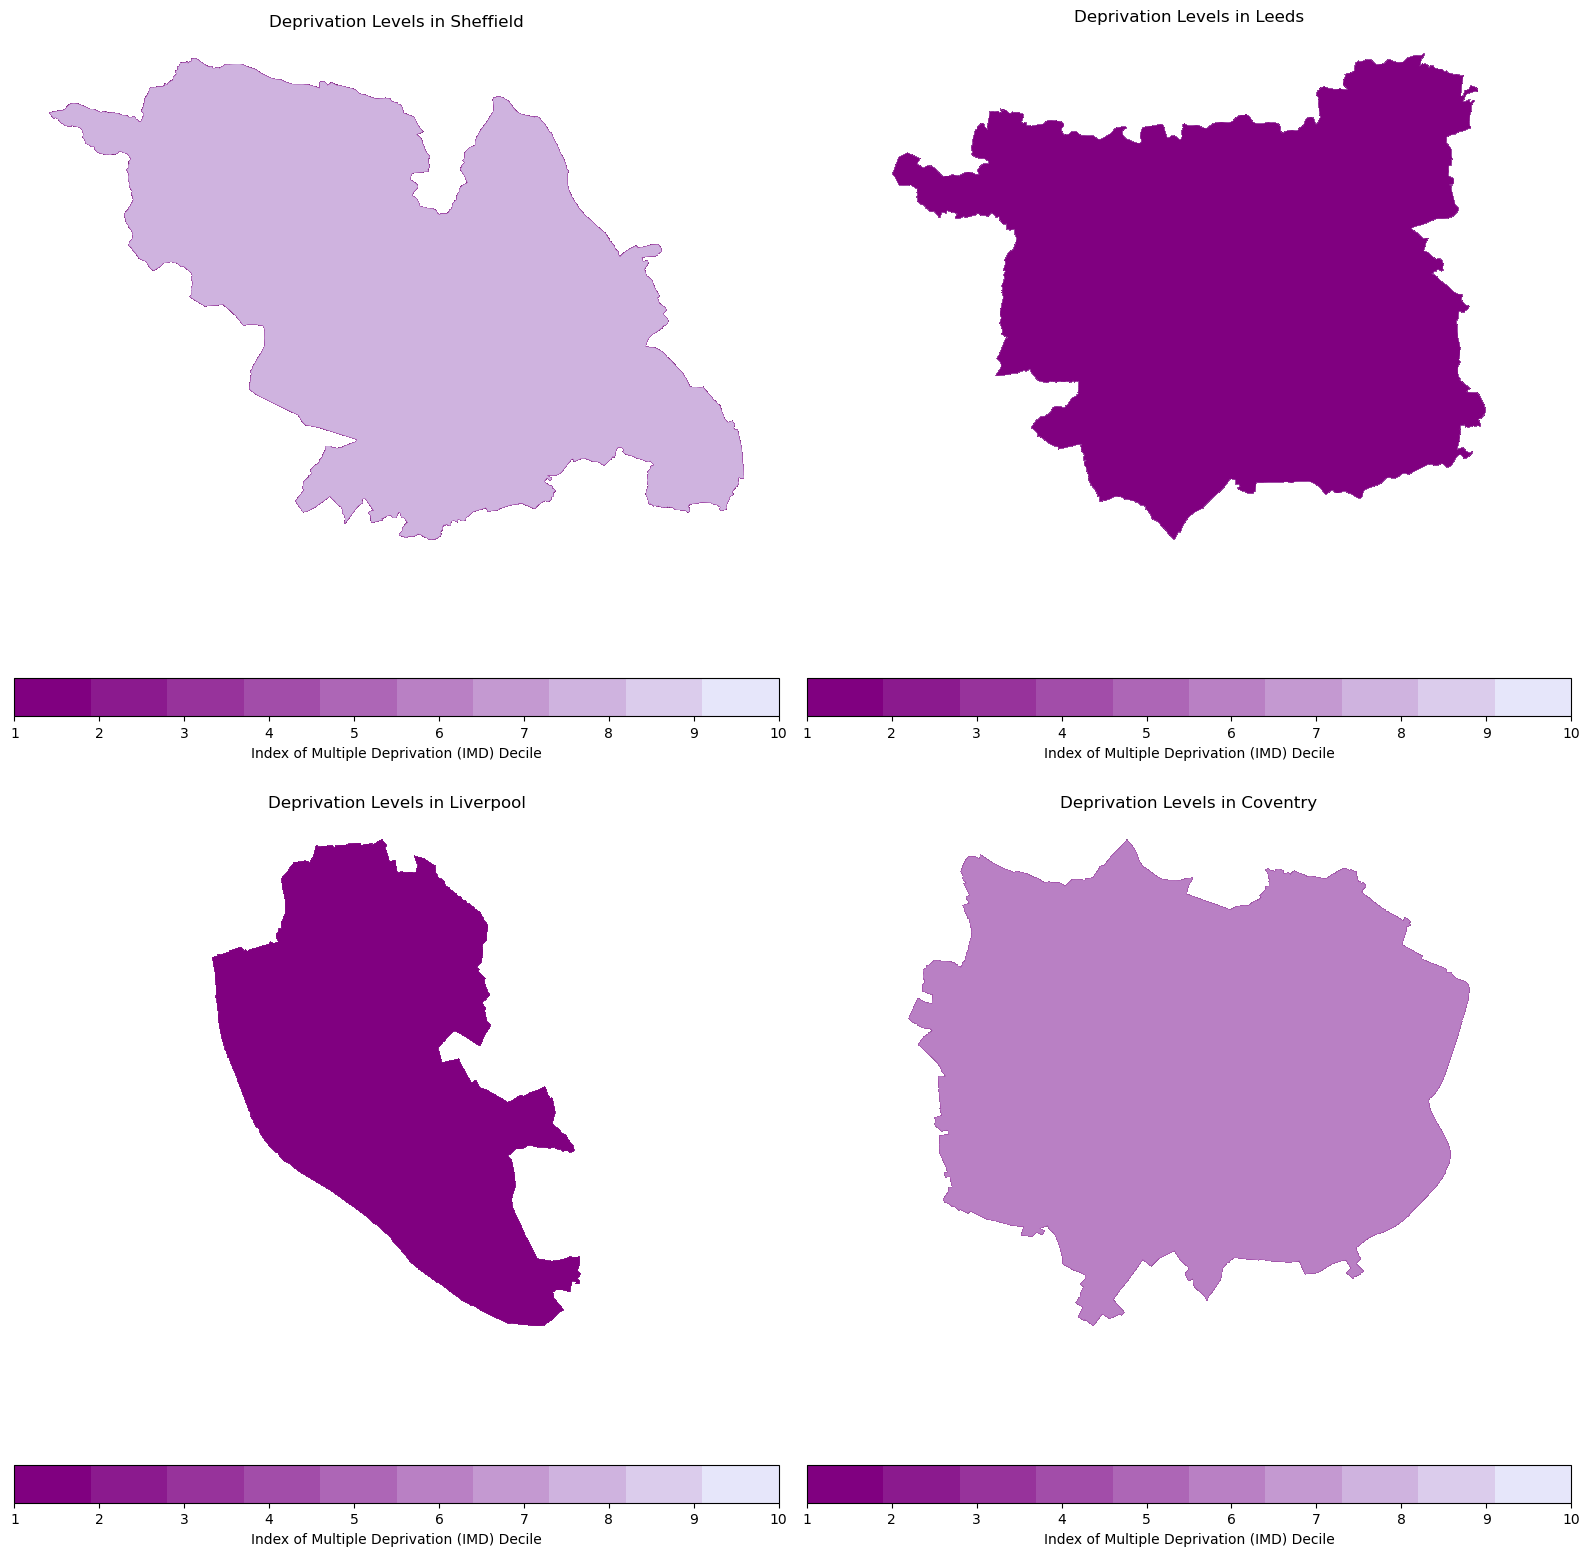

In [119]:
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_city_deprivation(city_data, city_name, ax):
    # Plotting using a colormap where lower deciles are darker
    # Creating a custom colormap that darkens with lower values
    from matplotlib.colors import LinearSegmentedColormap
    colors = ["purple", "lavender"]  # Darker to lighter
    cmap = LinearSegmentedColormap.from_list("custom_purple", colors, N=10)
    
    city_data.plot(column='Index of Multiple Deprivation (IMD) Decile', ax=ax, legend=True,
                   cmap=cmap,  # Custom colormap
                   legend_kwds={'label': "Index of Multiple Deprivation (IMD) Decile",
                                'orientation': "horizontal"})
    ax.set_title(f'Deprivation Levels in {city_name}')
    ax.set_axis_off()  # This hides the axis for a cleaner presentation

# Assuming 'merged_data' is your final GeoDataFrame
cities = ['Sheffield', 'Leeds', 'Liverpool', 'Coventry']
fig, axs = plt.subplots(2, 2, figsize=(16, 16))  # Create a 2x2 grid of subplots

# Flatten the array of axes to make iteration easier
axs = axs.flatten()

# Loop through the cities and plot each on its respective subplot
for i, city in enumerate(cities):
    city_data = merged_data[merged_data['Local Authority District name (2019)'].str.contains(city, na=False)]
    plot_city_deprivation(city_data, city, axs[i])

plt.tight_layout()  # Adjust subplots to fit into the figure area.
plt.show()


Low deciles (more purple shading) corresponds to the most deprived authorities. 

[//]: # (-.- .unlisted .unnumbered)

# Summary

In this Python walkthrough, you learned the essentials of creating geographical maps using Python. Key to this process is obtaining a shapefile that outlines the geographical boundaries of the entities you wish to visualize. Once you have the shapefile, you can enhance these maps by overlaying various data points according to specific variables. Here are the steps typically involved:

1. **Find and Download the Shapefile**: Locate the appropriate shapefile for your geographic entities. This file contains the geometry data needed to draw the boundaries of each entity on the map.

2. **Find and Download the Variable Data**: Acquire the data for the variables you wish to visualize (e.g., deprivation indices, population data). This data must correspond to the geographic entities in your shapefile.

3. **Merge the Data into the Shapefile**: Using Python, particularly libraries like Pandas and GeoPandas, merge your variable data with the shapefile. This involves aligning your data with the geographic entities based on a common key, such as an area code or name.

4. **Create the Map Using GeoPandas or Matplotlib**: Utilize GeoPandas to plot the merged data directly, or use Matplotlib for more detailed customization. For interactive maps, consider using Plotly, which allows for dynamic data exploration.

Mastering these mapping techniques in Python not only boosts your data visualization capabilities but also enhances your ability to analyze spatial data critically. This skill is invaluable across numerous fields, including urban planning, environmental monitoring, and public health.

This walkthrough is part of the [ECLR](https://datasquad.github.io/ECLR/) page.